# Notebook 4: Model and Tool Analysis

Per producer (LLM model or agentic tool) and budget arm.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from analysis.statistics import wilson_ci, fisher_min_p_value, bonferroni_correct
from analysis.plots import (metric_delta_distribution, outcome_classification_bar,
                            robustness_heatmap, timing_stacked_bar)

sns.set_theme(style='whitegrid')

DATA_DIR = Path(os.environ.get('ANALYSIS_DATA_DIR', '../../data'))
all_attempts = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv', low_memory=False)
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv', low_memory=False)
gen_tests = pd.read_csv(DATA_DIR / 'generated_tests.csv', low_memory=False)

# Infrastructure failures are missing data, not model or tool failures.
attempts = all_attempts[~all_attempts['infrastructure_failure'].astype(bool)]
llm = attempts[attempts['lane'] == 'llm']
agentic = attempts[attempts['lane'] == 'agentic']
llm_chains = candidates[candidates['lane'] == 'llm']
agentic_chains = candidates[candidates['lane'] == 'agentic']

## Participation

In [2]:
part = (all_attempts.assign(infrastructure=all_attempts['infrastructure_failure'].astype(bool))
        .groupby(['lane', 'producer', 'budget_mode'])['infrastructure']
        .agg(attempts='size', infrastructure_failures='sum'))
part['evaluable'] = part['attempts'] - part['infrastructure_failures']
display(part)

attempts  \
lane    producer                                    budget_mode                  
agentic aider-anthropic                             PassAt1                  4   
        aider-custom-glm                            PassAt1                  4   
        aider-custom-gpt                            PassAt1                  4   
        aider-custom-kimi                           PassAt1                  4   
        aider-gemini                                PassAt1                  4   
        aider-openai                                PassAt1                  4   
        claude                                      PassAt1                  4   
        codex                                       PassAt1                  4   
        copilot-anthropic                           PassAt1                  4   
        copilot-custom-glm                          PassAt1                  4   
        copilot-custom-gpt                          PassAt1                  4   
        copilot-custom-kimi                         PassAt1                  4   
        copilot-gemini                              PassAt1                  4   
        copilot-openai                              PassAt1                  4   
        gemini                                      PassAt1                  4   
        mini-swe-agent-anthropic                    PassAt1                  4   
        mini-swe-agent-custom-glm                   PassAt1                  4   
        mini-swe-agent-custom-gpt                   PassAt1                  4   
        mini-swe-agent-custom-kimi                  PassAt1                  4   
        mini-swe-agent-gemini                       PassAt1                  4   
        mini-swe-agent-openai                       PassAt1                  4   
        openhands-anthropic                         PassAt1                  4   
        openhands-custom-glm                        PassAt1                  4   
        openhands-custom-gpt                        PassAt1                  4   
        openhands-custom-kimi                       PassAt1                  4   
        openhands-gemini                            PassAt1                  4   
        openhands-openai                            PassAt1                  4   
llm     GLM-5.3-thinking-high                       PassAt1                  4   
                                                    PassAt1RepairAt5         9   
        Kimi-K3-thinking-high                       PassAt1                  4   
                                                    PassAt1RepairAt5        16   
        gemini-3.6-flash                            PassAt1                  4   
                                                    PassAt1RepairAt5         4   
        gpt-5.6-luna                                PassAt1                  4   
                                                    PassAt1RepairAt5         7   
        gpt-oss-120b                                PassAt1                  4   
                                                    PassAt1RepairAt5        12   
        us.anthropic.claude-haiku-4-5-20251001-v1:0 PassAt1                  4   
                                                    PassAt1RepairAt5        20   

                                                                      infrastructure_failures  \
lane    producer                                    budget_mode                                 
agentic aider-anthropic                             PassAt1                                 0   
        aider-custom-glm                            PassAt1                                 1   
        aider-custom-gpt                            PassAt1                                 0   
        aider-custom-kimi                           PassAt1                                 2   
        aider-gemini                                PassAt1                                 0   
        aider-openai        

## Validated success with 95% Wilson intervals

,producer,n,successes,rate,ci_lower,ci_upper
1,Kimi-K3-thinking-high,2,2,1.00,0.342,1.000
2,gemini-3.6-flash,4,4,1.00,0.510,1.000
3,gpt-5.6-luna,4,3,0.75,0.301,0.954
4,gpt-oss-120b,4,3,0.75,0.301,0.954
0,GLM-5.3-thinking-high,4,1,0.25,0.046,0.699
5,us.anthropic.claude-haiku-4-5-20251001-v1:0,0,0,NaN,NaN,NaN


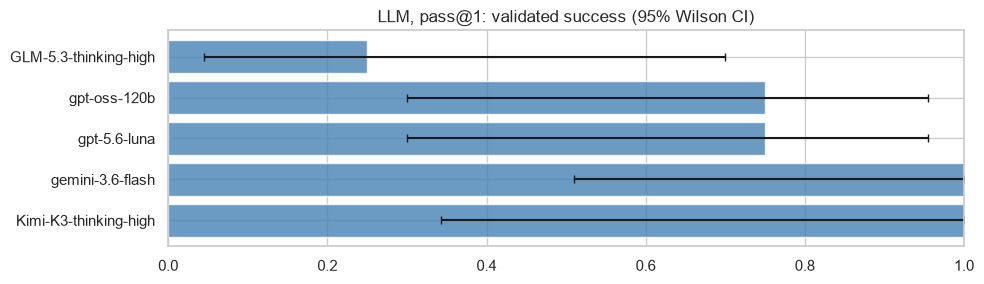

10 pairs, Bonferroni threshold 0.005, smallest reachable Fisher p 0.029: pairwise tests skipped.


,producer,n,successes,rate,ci_lower,ci_upper
0,GLM-5.3-thinking-high,4,4,1.00,0.510,1.000
1,Kimi-K3-thinking-high,2,2,1.00,0.342,1.000
2,gemini-3.6-flash,4,4,1.00,0.510,1.000
3,gpt-5.6-luna,4,4,1.00,0.510,1.000
4,gpt-oss-120b,4,3,0.75,0.301,0.954
5,us.anthropic.claude-haiku-4-5-20251001-v1:0,0,0,NaN,NaN,NaN


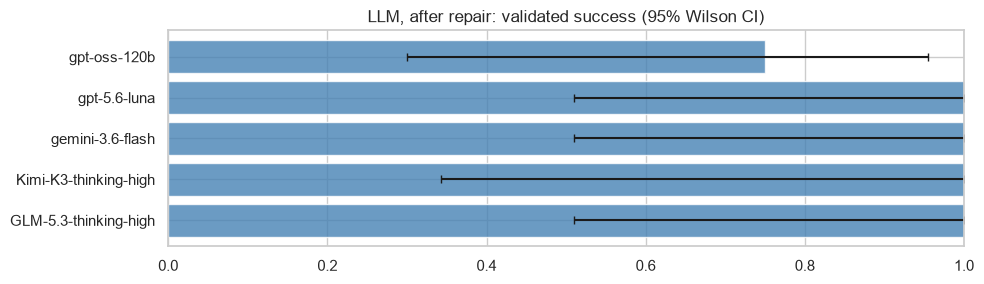

10 pairs, Bonferroni threshold 0.005, smallest reachable Fisher p 0.029: pairwise tests skipped.


,producer,n,successes,rate,ci_lower,ci_upper
0,aider-anthropic,4,4,1.000,0.510,1.000
6,claude,4,4,1.000,0.510,1.000
3,aider-custom-kimi,2,2,1.000,0.342,1.000
9,copilot-custom-glm,4,4,1.000,0.510,1.000
7,codex,4,4,1.000,0.510,1.000
25,openhands-gemini,4,4,1.000,0.510,1.000
16,mini-swe-agent-custom-glm,4,4,1.000,0.510,1.000
14,gemini,4,4,1.000,0.510,1.000
13,copilot-openai,4,4,1.000,0.510,1.000
12,copilot-gemini,4,4,1.000,0.510,1.000


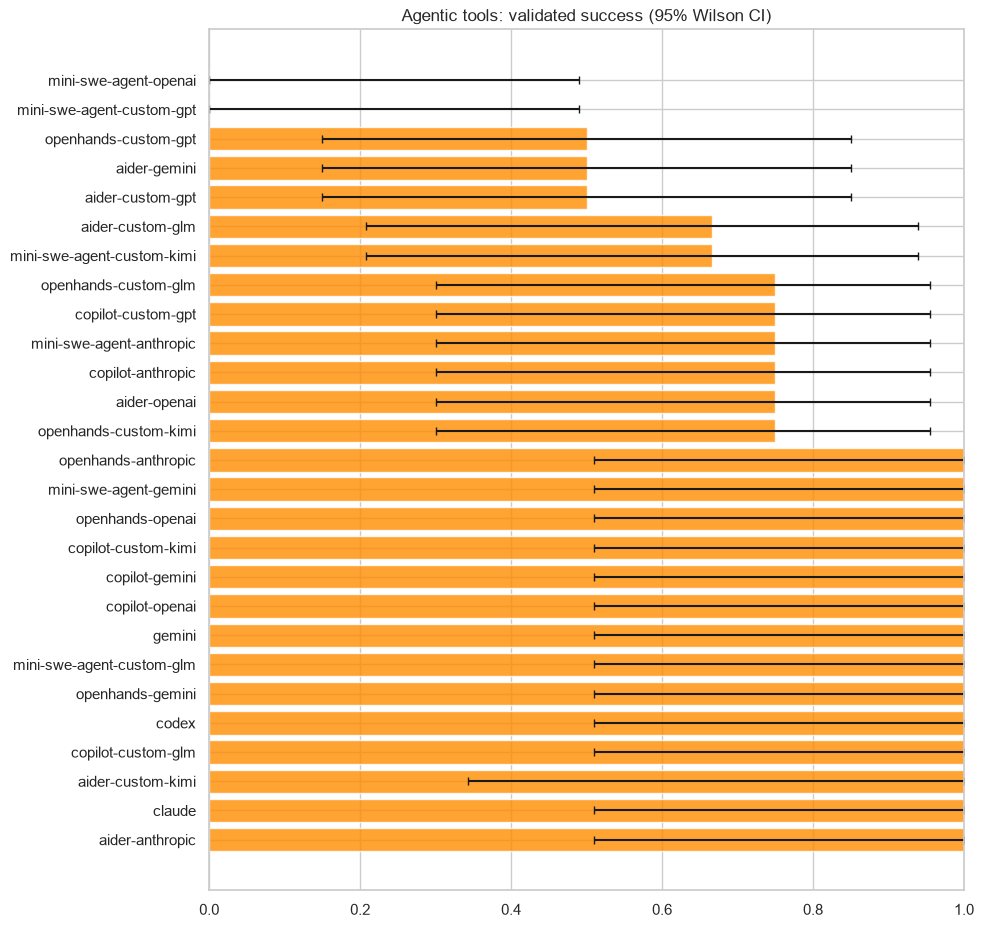

351 pairs, Bonferroni threshold 0.00014, smallest reachable Fisher p 0.029: pairwise tests skipped.


In [3]:
def rate_table(chains, outcome):
    rows = []
    for producer, g in chains.groupby('producer'):
        known = g[outcome].dropna().astype(bool)
        k, n = int(known.sum()), len(known)
        low, high = wilson_ci(k, n)
        rows.append({'producer': producer, 'n': n, 'successes': k,
                     'rate': k / n if n else float('nan'), 'ci_lower': low, 'ci_upper': high})
    return pd.DataFrame(rows).sort_values('rate', ascending=False, na_position='last')


def pairwise_fisher(table, alpha=0.05):
    """Pairwise Fisher's exact tests with Bonferroni; skipped when no pair could reject."""
    rows = list(table[table['n'] > 0].itertuples())
    pairs = [(a, b) for i, a in enumerate(rows) for b in rows[i + 1:]]
    if not pairs:
        return
    threshold = alpha / len(pairs)
    reachable = min(fisher_min_p_value(a.n, b.n) for a, b in pairs)
    if reachable > threshold:
        print(f'{len(pairs)} pairs, Bonferroni threshold {threshold:.2g}, smallest reachable '
              f'Fisher p {reachable:.3f}: pairwise tests skipped.')
        return
    p_values = [stats.fisher_exact([[a.successes, a.n - a.successes],
                                    [b.successes, b.n - b.successes]])[1] for a, b in pairs]
    corr = bonferroni_correct(p_values, alpha=alpha)
    display(pd.DataFrame({
        'comparison': [f'{a.producer} vs {b.producer}' for a, b in pairs],
        'rate_diff': [round(a.rate - b.rate, 3) for a, b in pairs],
        'p_value': [round(p, 4) for p in p_values],
        f"sig (alpha={corr['alpha_corrected']:.2g})": corr['reject'],
    }))


def plot_rates(table, title, color):
    shown = table.dropna(subset=['rate'])
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(shown))))
    ax.barh(shown['producer'], shown['rate'],
            xerr=[shown['rate'] - shown['ci_lower'], shown['ci_upper'] - shown['rate']],
            capsize=3, color=color, alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


SETS = [('LLM, pass@1', llm_chains[llm_chains['budget_mode'] == 'PassAt1'], 'first_attempt_success', 'steelblue'),
        ('LLM, after repair', llm_chains[llm_chains['budget_mode'] == 'PassAt1RepairAt5'], 'any_validated_success', 'steelblue'),
        ('Agentic tools', agentic_chains, 'first_attempt_success', 'darkorange')]
for label, chains, outcome, color in SETS:
    table = rate_table(chains, outcome)
    display(table.round(3))
    plot_rates(table, f'{label}: validated success (95% Wilson CI)', color)
    pairwise_fisher(table)

## Coverage delta and outcomes by producer

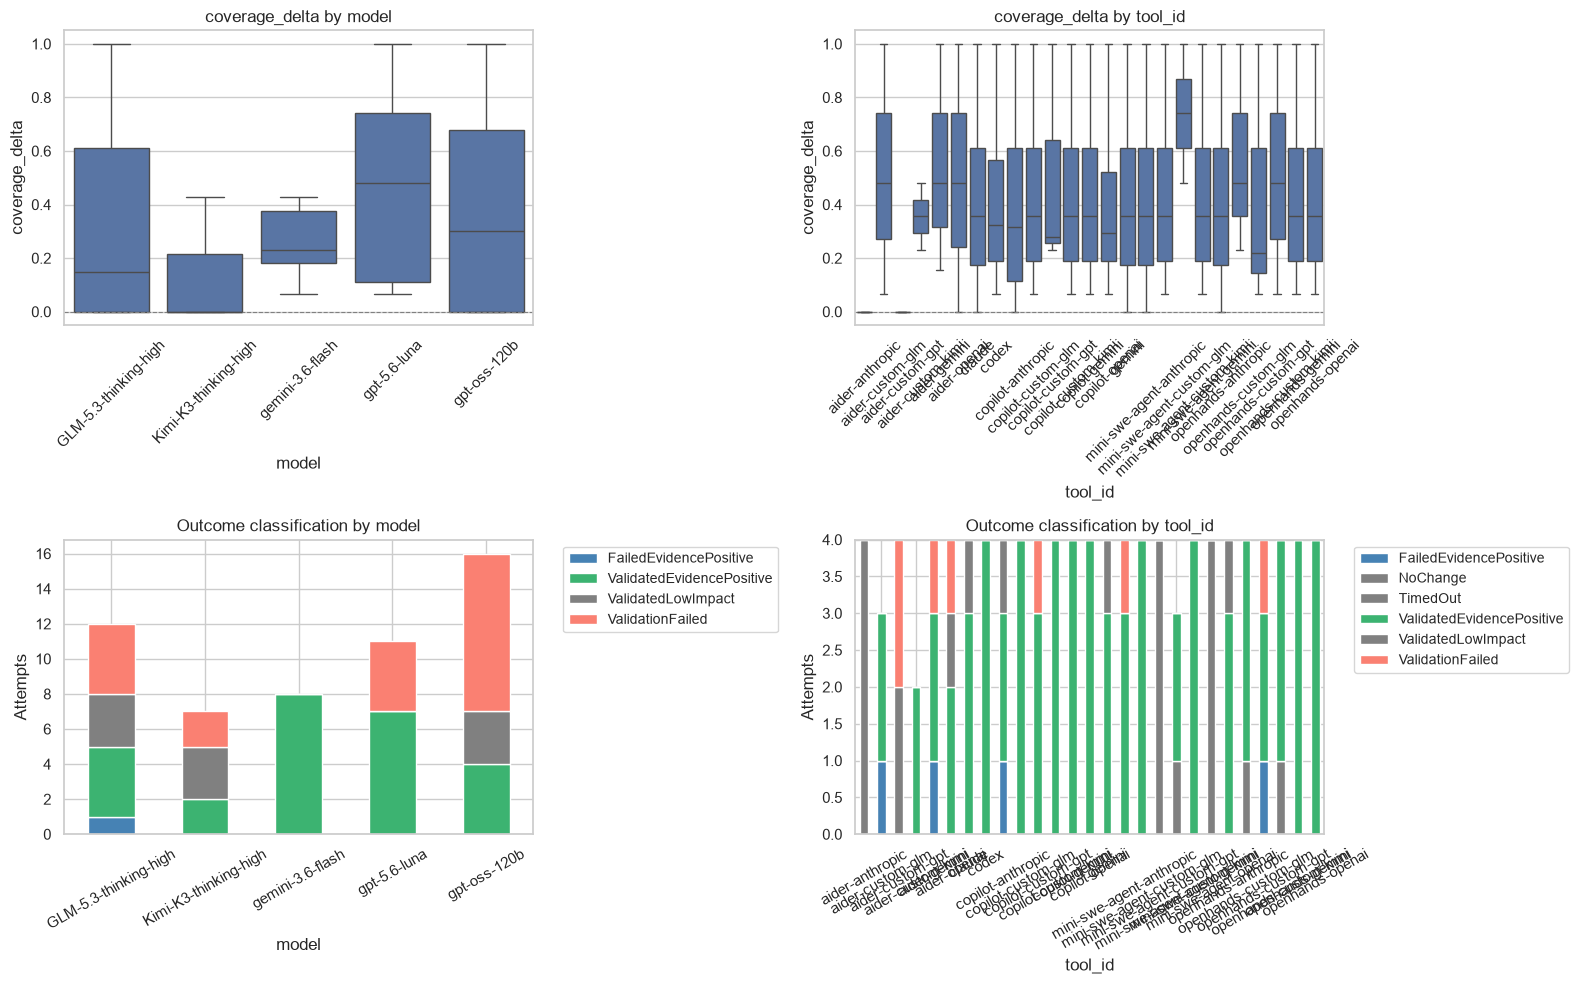

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metric_delta_distribution(llm, 'coverage_delta', 'model', ax=axes[0][0])
metric_delta_distribution(agentic, 'coverage_delta', 'tool_id', ax=axes[0][1])
outcome_classification_bar(llm, group_col='model', ax=axes[1][0])
outcome_classification_bar(agentic, group_col='tool_id', ax=axes[1][1])
plt.tight_layout()
plt.show()

## Robustness across repositories

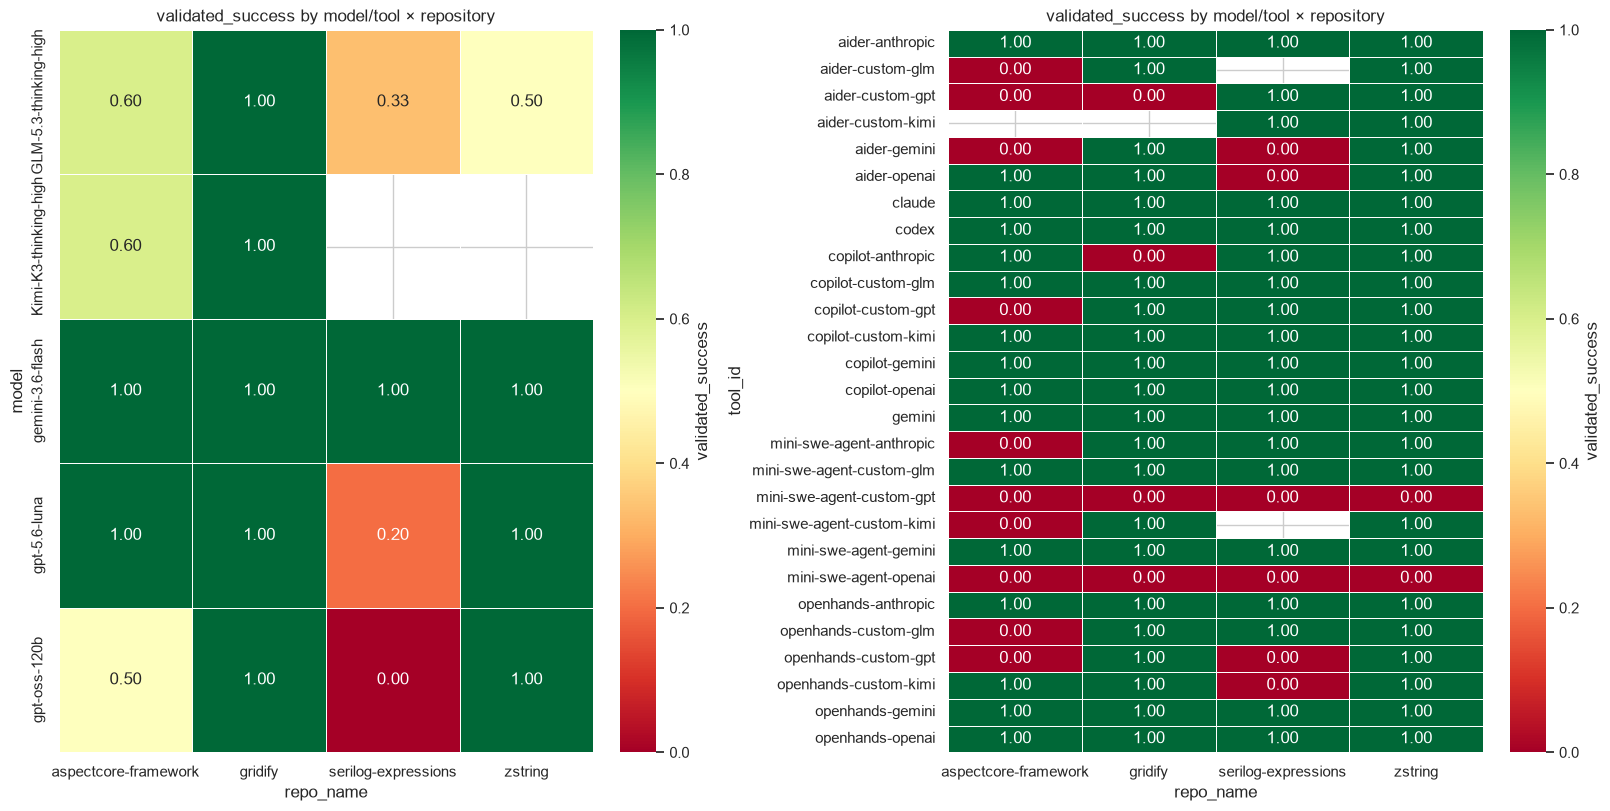

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), layout='constrained')
robustness_heatmap(llm, 'model', 'repo_name', 'validated_success', ax=axes[0])
robustness_heatmap(agentic, 'tool_id', 'repo_name', 'validated_success', ax=axes[1])
plt.show()

## Producer summary and cost frontier

,lane,producer,n,success_rate,vep_rate,min_repo_success,median_tokens,successes_per_1k_tokens,on_frontier
0,agentic,aider-anthropic,4,1.000,0.000,1.0,17628.5,0.054,False
3,agentic,aider-custom-kimi,2,1.000,1.000,1.0,14050.0,0.071,False
6,agentic,claude,4,1.000,0.750,1.0,724496.0,0.001,False
7,agentic,codex,4,1.000,1.000,1.0,533208.5,0.002,False
9,agentic,copilot-custom-glm,4,1.000,1.000,1.0,1481832.0,0.001,False
11,agentic,copilot-custom-kimi,4,1.000,1.000,1.0,320480.5,0.003,False
12,agentic,copilot-gemini,4,1.000,1.000,1.0,1232528.5,0.001,False
13,agentic,copilot-openai,4,1.000,1.000,1.0,302977.5,0.003,False
14,agentic,gemini,4,1.000,0.750,1.0,660359.5,0.001,False
16,agentic,mini-swe-agent-custom-glm,4,1.000,1.000,1.0,NaN,NaN,False


No recorded token usage: mini-swe-agent-anthropic, mini-swe-agent-custom-glm, mini-swe-agent-custom-gpt, mini-swe-agent-custom-kimi, mini-swe-agent-gemini, mini-swe-agent-openai, openhands-anthropic, openhands-custom-glm, openhands-custom-gpt, openhands-custom-kimi, openhands-gemini, openhands-openai


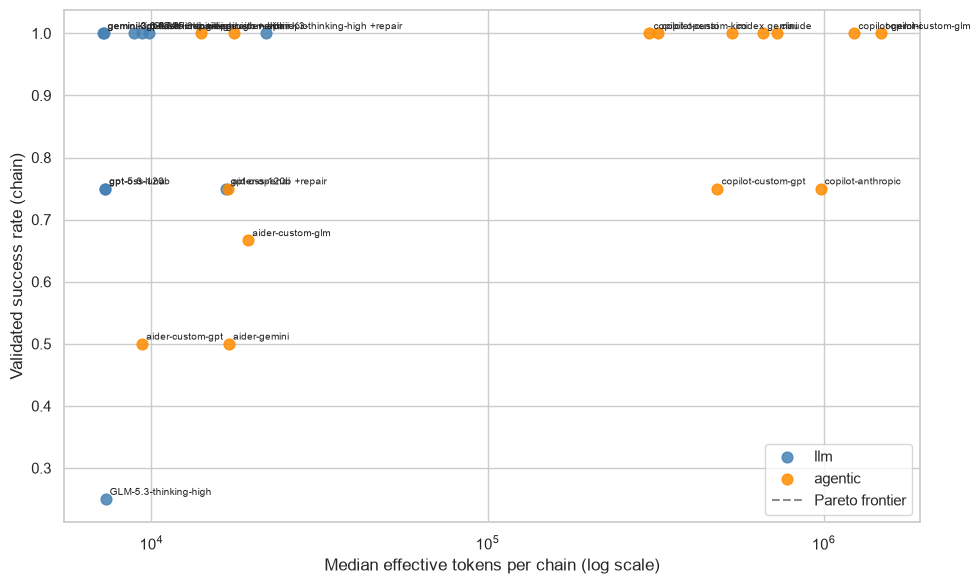

In [6]:
prod = candidates[candidates['any_validated_success'].notna()].copy()
prod['label'] = prod['producer'].where(prod['budget_mode'].ne('PassAt1RepairAt5'), prod['producer'] + ' +repair')
rows = []
for (lane, label), g in prod.groupby(['lane', 'label']):
    success = g['any_validated_success'].astype(bool)
    with_usage = g[g['effective_tokens'].notna()]
    tokens = with_usage['effective_tokens'].sum()
    rows.append({
        'lane': lane, 'producer': label, 'n': len(g),
        'success_rate': success.mean(),
        'vep_rate': g['any_positive_impact'].dropna().astype(bool).mean(),
        'min_repo_success': g.assign(s=success).groupby('repository_key')['s'].mean().min(),
        'median_tokens': with_usage['effective_tokens'].median() if len(with_usage) else np.nan,
        'successes_per_1k_tokens': (with_usage['any_validated_success'].astype(bool).sum() / (tokens / 1000)
                                    if tokens > 0 else np.nan),
    })
summary = pd.DataFrame(rows)
costed = summary.dropna(subset=['median_tokens'])
# Pareto frontier: no other producer is at least as cheap and as successful, and better on one.
summary['on_frontier'] = [
    pd.notna(r.median_tokens) and not (
        (costed['median_tokens'] <= r.median_tokens) & (costed['success_rate'] >= r.success_rate)
        & ((costed['median_tokens'] < r.median_tokens) | (costed['success_rate'] > r.success_rate))).any()
    for r in summary.itertuples()]
display(summary.sort_values(['lane', 'success_rate'], ascending=[True, False]).round(3))
no_usage = summary.loc[summary['median_tokens'].isna(), 'producer']
if len(no_usage):
    print(f'No recorded token usage: {", ".join(no_usage)}')

fig, ax = plt.subplots(figsize=(10, 6))
for lane, color in [('llm', 'steelblue'), ('agentic', 'darkorange')]:
    s = costed[costed['lane'] == lane]
    ax.scatter(s['median_tokens'], s['success_rate'], c=color, s=60, alpha=0.85, label=lane)
    for r in s.itertuples():
        ax.annotate(r.producer, (r.median_tokens, r.success_rate), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
frontier = summary[summary['on_frontier']].sort_values('median_tokens')
ax.plot(frontier['median_tokens'], frontier['success_rate'], 'k--', alpha=0.5, label='Pareto frontier')
ax.set_xscale('log')
ax.set_xlabel('Median effective tokens per chain (log scale)')
ax.set_ylabel('Validated success rate (chain)')
ax.legend()
plt.tight_layout()
plt.show()

## Runtime by producer

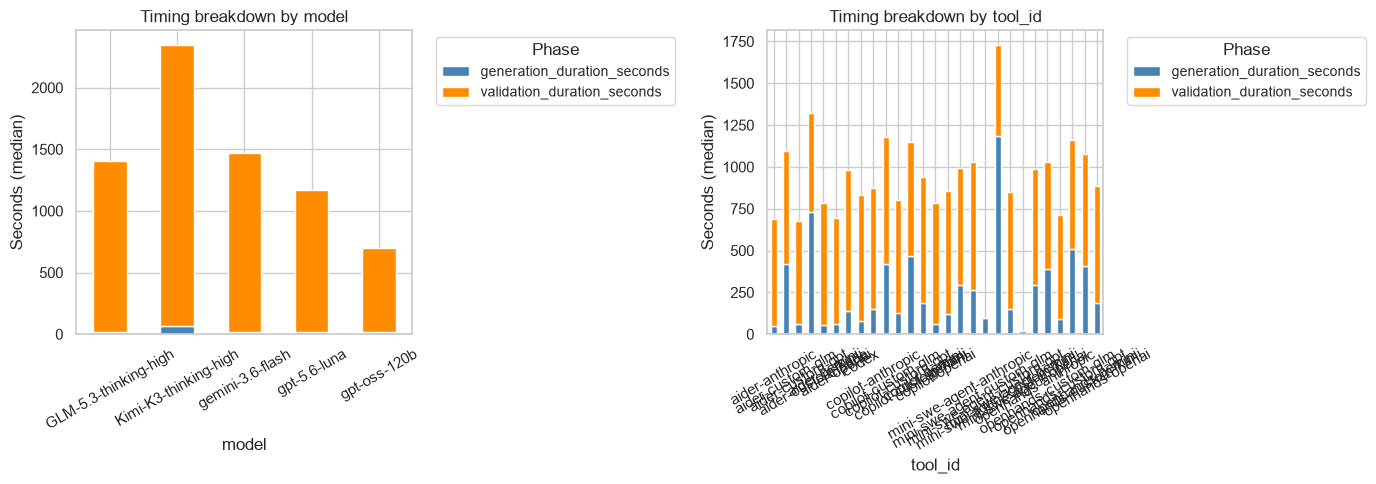

generation_duration_seconds  \
lane    producer                                                  
agentic aider-anthropic                                    48.8   
        aider-custom-glm                                  418.4   
        aider-custom-gpt                                   61.2   
        aider-custom-kimi                                 730.7   
        aider-gemini                                       52.4   
        aider-openai                                       63.4   
        claude                                            137.5   
        codex                                              78.1   
        copilot-anthropic                                 149.0   
        copilot-custom-glm                                421.6   
        copilot-custom-gpt                                125.7   
        copilot-custom-kimi                               468.3   
        copilot-gemini                                    185.6   
        copilot-openai                                     62.0   
        gemini                                            122.2   
        mini-swe-agent-anthropic                          294.2   
        mini-swe-agent-custom-glm                         267.1   
        mini-swe-agent-custom-gpt                          96.6   
        mini-swe-agent-custom-kimi                       1182.0   
        mini-swe-agent-gemini                             149.3   
        mini-swe-agent-openai                              21.9   
        openhands-anthropic                               294.2   
        openhands-custom-glm                              388.2   
        openhands-custom-gpt                               89.0   
        openhands-custom-kimi                             510.1   
        openhands-gemini                                  406.9   
        openhands-openai                                  189.1   
llm     GLM-5.3-thinking-high                              15.2   
        Kimi-K3-thinking-high                              64.7   
        gemini-3.6-flash                                   14.9   
        gpt-5.6-luna                                       16.3   
        gpt-oss-120b                                       17.1   

                                    validation_duration_seconds  
lane    producer                                                 
agentic aider-anthropic                                   639.3  
        aider-custom-glm                                  674.6  
        aider-custom-gpt                                  613.0  
        aider-custom-kimi                                 589.1  
        aider-gemini                                      731.4  
        aider-openai                                      633.0  
        claude                                            845.1  
        codex                                             755.4  
        copilot-anthropic                                 723.9  
        copilot-custom-glm                                759.4  
        copilot-custom-gpt                                677.4  
        copilot-custom-kimi                               679.0  
        copilot-gemini                                    755.4  
        copilot-openai                                    720.5  
        gemini                                            734.8  
        mini-swe-agent-anthropic                          696.9  
        mini-swe-agent-custom-glm                         761.5  
        mini-swe-agent-custom-gpt                           0.0  
        mini-swe-agent-custom-kimi                        546.9  
        mini-swe-agent-gemini                             700.8  
        mini-swe-agent-openai                               0.0  
        openhands-anthropic                               690.6  
        openhands-custom-glm                              639.9  
        openhands-custom-gpt                              622.6  
        openhands-custom-kimi            

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
timing_stacked_bar(llm, group_col='model', ax=axes[0])
timing_stacked_bar(agentic, group_col='tool_id', ax=axes[1])
plt.tight_layout()
plt.show()
display(attempts.groupby(['lane', 'producer'])[['generation_duration_seconds', 'validation_duration_seconds']]
        .median().round(1))

## Test smells by producer

tests  smells_per_test
lane    producer                                          
agentic aider-gemini                    9             2.22
        aider-custom-gpt                3             2.00
llm     gpt-5.6-luna                   11             1.82
        gpt-oss-120b                   16             1.81
agentic copilot-anthropic              42             1.67
        mini-swe-agent-custom-kimi     11             1.64
        claude                         26             1.62
        aider-openai                    5             1.60
        aider-custom-glm               29             1.59
        codex                          15             1.53
        openhands-anthropic            51             1.53
llm     GLM-5.3-thinking-high          12             1.50
        gemini-3.6-flash                8             1.50
agentic openhands-custom-glm           17             1.47
        openhands-custom-kimi          34             1.44
llm     Kimi-K3-thinking-high           7             1.43
agentic copilot-custom-gpt             12             1.42
        copilot-custom-kimi            18             1.39
        openhands-gemini               16             1.38
        mini-swe-agent-anthropic       67             1.36
        copilot-openai                 12             1.33
        copilot-gemini                 24             1.33
        mini-swe-agent-custom-glm      49             1.33
        openhands-openai               12             1.25
        aider-custom-kimi              11             1.18
        gemini                         28             1.18
        mini-swe-agent-gemini          24             1.17
        copilot-custom-glm             36             1.11
        openhands-custom-gpt           12             1.08

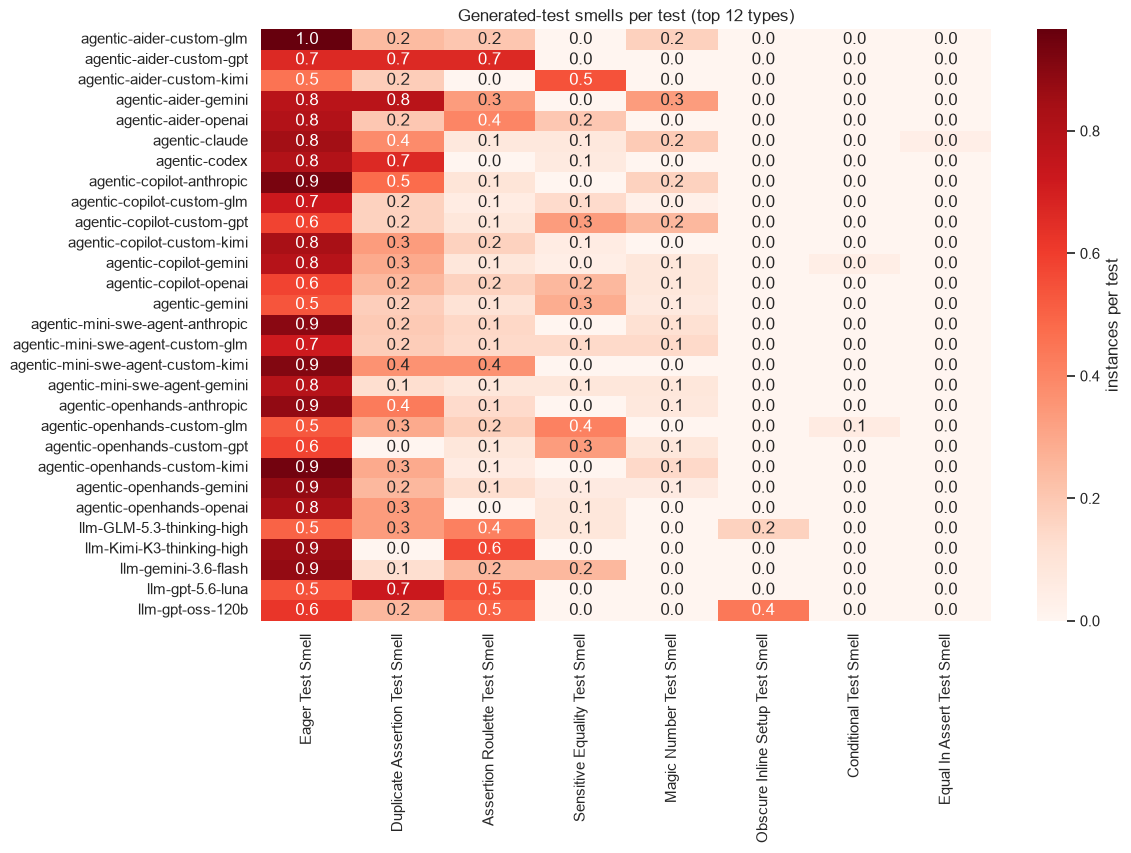

In [8]:
def parse_smells(value):
    counts = {}
    if isinstance(value, str):
        for part in value.split(';'):
            name, _, count = part.strip().rpartition('=')
            name = name.strip()
            if name:
                try:
                    counts[name] = counts.get(name, 0) + int(count)
                except ValueError:
                    counts[name] = counts.get(name, 0) + 1
    return counts


smells = pd.DataFrame([{'lane': r.lane, 'producer': r.producer, **parse_smells(r.generated_test_smells)}
                       for r in gen_tests.itertuples()]).fillna(0)
grouped = smells.groupby(['lane', 'producer'])
per_test = grouped.mean(numeric_only=True)
display(pd.DataFrame({'tests': grouped.size(), 'smells_per_test': per_test.sum(axis=1)})
        .sort_values('smells_per_test', ascending=False).round(2))
types = per_test.loc[:, per_test.sum().sort_values(ascending=False).index[:12]]
fig, ax = plt.subplots(figsize=(12, max(4, 0.3 * len(types))))
sns.heatmap(types, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'instances per test'}, ax=ax)
ax.set_ylabel('')
ax.set_title('Generated-test smells per test (top 12 types)')
plt.tight_layout()
plt.show()

## Success predictors

In [9]:
# Structural family (sign: +1 increases with complexity; MI is inverse).
STRUCT = [('source_method_cc', 1), ('source_method_sloc', 1), ('source_method_eloc', 1),
          ('source_method_coupling', 1), ('source_method_dit', 1), ('source_method_mi', -1)]
struct_cols = [(c, s) for c, s in STRUCT if c in candidates.columns]
distinct_numeric = [c for c in ['source_method_baseline_coverage', 'test_mapping_count']
                    if c in candidates.columns]

# One row per distinct source method (metrics are method properties, constant across chains).
methods = (candidates.drop_duplicates('candidate_key').set_index('candidate_key')
           [[c for c, _ in struct_cols] + distinct_numeric].apply(pd.to_numeric, errors='coerce'))

# z-score + sign-align -> equal-weight complexity_index (robust at small N).
z = pd.DataFrame({c: (sign * (methods[c] - methods[c].mean()) / methods[c].std(ddof=0)
                      if methods[c].std(ddof=0) > 0 else 0.0)
                  for c, sign in struct_cols}, index=methods.index)
complexity_index = z.mean(axis=1)

PCA_MIN = 20
if len(methods) >= PCA_MIN and len(struct_cols) >= 2:
    # Dependency-free PCA via SVD on the standardized matrix.
    M = z.to_numpy(dtype=float)
    M = M - M.mean(axis=0)
    _, S, Vt = np.linalg.svd(M, full_matrices=False)
    pc1 = M @ Vt[0]
    if Vt[0][0] < 0:  # sign-align so higher index = more complex
        pc1 = -pc1
    complexity_index = pd.Series(pc1, index=methods.index)
    print(f'complexity_index = PC1 ({(S[0] ** 2) / (S ** 2).sum():.0%} of variance), {len(methods)} methods')
else:
    print(f'complexity_index = equal-weight z-average ({len(methods)} methods < {PCA_MIN} for PCA)')
display(methods.corr().round(2))

# Screen predictors against the chain outcome (chains repeat each method across producers).
cat_cols = [c for c in ['access_strategy', 'source_member_visibility'] if c in candidates.columns]
scr = (candidates[['candidate_key', 'any_validated_success'] + distinct_numeric + cat_cols]
       .merge(complexity_index.rename('complexity_index'), left_on='candidate_key',
              right_index=True, how='left'))
scr = scr[scr['any_validated_success'].notna()]
rows = []
for p in ['complexity_index'] + distinct_numeric:
    d = scr[[p, 'any_validated_success']].copy()
    d[p] = pd.to_numeric(d[p], errors='coerce')
    d = d.dropna()
    y = d['any_validated_success'].astype(bool).astype(float)
    r = (np.corrcoef(d[p], y)[0, 1]
         if d[p].nunique() > 1 and y.nunique() > 1 and len(d) > 2 else float('nan'))
    rows.append({'predictor': p, 'n': len(d), 'distinct': int(d[p].nunique()),
                 'point_biserial_r': round(r, 3) if r == r else None})
for c in cat_cols:
    rows.append({'predictor': c, 'n': int(scr[c].notna().sum()), 'distinct': int(scr[c].nunique())})
# A predictor with one distinct value cannot explain success at any N.
display(pd.DataFrame(rows))

complexity_index = equal-weight z-average (4 methods < 20 for PCA)


,source_method_cc,source_method_sloc,source_method_eloc,source_method_coupling,source_method_dit,source_method_mi,source_method_baseline_coverage,test_mapping_count
source_method_cc,1.00,0.82,0.82,0.64,NaN,-0.90,0.67,NaN
source_method_sloc,0.82,1.00,0.98,0.08,NaN,-0.95,0.54,NaN
source_method_eloc,0.82,0.98,1.00,0.10,NaN,-0.98,0.40,NaN
source_method_coupling,0.64,0.08,0.10,1.00,NaN,-0.27,0.48,NaN
source_method_dit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_method_mi,-0.90,-0.95,-0.98,-0.27,NaN,1.00,-0.43,NaN
source_method_baseline_coverage,0.67,0.54,0.40,0.48,NaN,-0.43,1.00,NaN
test_mapping_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,predictor,n,distinct,point_biserial_r
0,complexity_index,140,4,-0.063
1,source_method_baseline_coverage,140,4,-0.204
2,test_mapping_count,140,1,NaN
3,access_strategy,140,1,NaN
4,source_member_visibility,140,1,NaN


## Repair efficacy (`PassAt1RepairAt5` arm)

In [10]:
repair = all_attempts[(all_attempts['lane'] == 'llm')
                      & (all_attempts['budget_mode'] == 'PassAt1RepairAt5')].copy()
repair['attempt_number'] = pd.to_numeric(repair['attempt_number'], errors='coerce')
rows = []
for (ck, model), g in repair.groupby(['candidate_key', 'producer']):
    g = g.sort_values('attempt_number')
    # A chain whose first attempt failed on infrastructure has no pass@1 to repair.
    if bool(g['infrastructure_failure'].iloc[0]):
        continue
    evaluable = g[~g['infrastructure_failure'].astype(bool)]
    succ = evaluable['validated_success'].fillna(False).astype(bool).to_numpy()
    ever = bool(succ.any())
    first = bool(succ[0])
    rows.append({
        'candidate': str(ck).split('|')[-1], 'model': model, 'attempts': len(g),
        'first_try_success': first, 'ever_success': ever,
        'success_at_attempt': int(evaluable['attempt_number'].iloc[int(np.argmax(succ))]) if ever else None,
        'rescued_by_repair': ever and not first,
        'chain_tokens': pd.to_numeric(g['cumulative_tokens'], errors='coerce').max(),
    })
chain = pd.DataFrame(rows)
display(chain)
display(chain.groupby('model').agg(
    chains=('first_try_success', 'size'),
    first_try_rate=('first_try_success', 'mean'),
    needed_repair=('first_try_success', lambda s: int((~s).sum())),
    rescued=('rescued_by_repair', 'sum'),
    final_success_rate=('ever_success', 'mean')).round(3))

,candidate,model,attempts,first_try_success,ever_success,success_at_attempt,rescued_by_repair,chain_tokens
0,129,GLM-5.3-thinking-high,1,True,True,1.0,False,6824.0
1,129,Kimi-K3-thinking-high,1,True,True,1.0,False,6691.0
2,129,gemini-3.6-flash,1,True,True,1.0,False,6709.0
3,129,gpt-5.6-luna,1,True,True,1.0,False,6772.0
4,129,gpt-oss-120b,1,True,True,1.0,False,6824.0
5,432,GLM-5.3-thinking-high,1,True,True,1.0,False,7997.0
6,432,gemini-3.6-flash,1,True,True,1.0,False,7715.0
7,432,gpt-5.6-luna,1,True,True,1.0,False,7815.0
8,432,gpt-oss-120b,1,True,True,1.0,False,7853.0
9,259,GLM-5.3-thinking-high,5,True,True,1.0,False,33038.0


,chains,first_try_rate,needed_repair,rescued,final_success_rate
model,,,,,
GLM-5.3-thinking-high,4,0.75,1,1,1.00
Kimi-K3-thinking-high,2,0.50,1,1,1.00
gemini-3.6-flash,4,1.00,0,0,1.00
gpt-5.6-luna,4,0.75,1,1,1.00
gpt-oss-120b,4,0.75,1,0,0.75
